In [ ]:
!pip install skimpy xgboost lightgbm causalml econml dowhy imblearn plotly seaborn pyngrok mlflow scipy

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import skimpy as sk
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as ss
from statsmodels.api import *
import mlflow
import mlflow.sklearn
from pyngrok import *
from dowhy import *
from causalml import *
from imblearn.over_sampling import *

from sklearn.preprocessing import *
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.model_selection import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib
from warnings import filterwarnings; filterwarnings("ignore")

ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


In [ ]:
train_features = pd.read_csv("training_data.csv")
train_labels = pd.read_csv("training_labels.csv")
train_df = pd.merge(train_features, train_labels, on="id")
train_df

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


In [ ]:
test_df = pd.read_csv("testing_data.csv")
test_df

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,...,never pay,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,...,unknown,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,...,monthly,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14845,39307,0.0,2011-02-24,Danida,34,Da,38.852669,-6.582841,Kwambwezi,0,...,never pay,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe
14846,18990,1000.0,2011-03-21,Hiap,0,HIAP,37.451633,-5.350428,Bonde La Mkondoa,0,...,annually,salty,salty,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump
14847,28749,0.0,2013-03-04,NaN,1476,NaN,34.739804,-4.585587,Bwawani,0,...,never pay,soft,good,insufficient,insufficient,dam,dam,surface,communal standpipe,communal standpipe
14848,33492,0.0,2013-02-18,Germany,998,DWE,35.432732,-10.584159,Kwa John,0,...,never pay,soft,good,insufficient,insufficient,river,river/lake,surface,communal standpipe,communal standpipe


In [ ]:
train_df.isnull().sum()

,0
id,0
amount_tsh,0
date_recorded,0
funder,3637
gps_height,0
installer,3655
longitude,0
latitude,0
wpt_name,2
num_private,0


In [ ]:
test_df.isnull().sum()

,0
id,0
amount_tsh,0
date_recorded,0
funder,870
gps_height,0
installer,877
longitude,0
latitude,0
wpt_name,0
num_private,0


In [ ]:
list(train_df.columns) == list(test_df.columns)

False

In [ ]:
# Imputing
imputers = {}

feature_cols = [col for col in train_df.select_dtypes(include="object").columns if col != "status_group"]

for col in feature_cols:
    imputer = SimpleImputer(strategy="most_frequent")
    train_df[col] = imputer.fit_transform(train_df[[col]]).ravel()
    test_df[col] = imputer.transform(test_df[[col]]).ravel()
    imputers[col] = imputer

# Label Encoding
label_encoders = {}

for col in feature_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = test_df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    label_encoders[col] = le

# Encode target separately
target_le = LabelEncoder()
train_df["status_group"] = target_le.fit_transform(train_df["status_group"])

#EDA

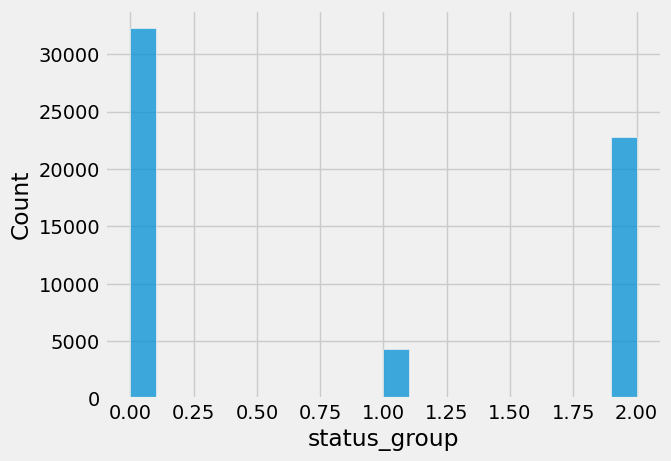

In [ ]:
#Trying to see if there is fat tail/low tail distribution
sns.histplot(train_df["status_group"])
plt.savefig("Fat Tail Distribution Sanity Check.png")
plt.show()

In [ ]:
sk.skim(train_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 59400  │ │ int64       │ 38    │                                                          │
│ │ Number of columns │ 41     │ │ float64     │ 3     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                ┃ NA  ┃ NA % ┃ mean   ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ id                    │   0 │    0 │  37120 │  21450 │      0 │  18520 │  37060 │  55660 │  74250 │ ██████ │  │
│ │ amount_tsh            │   0 │    0 │  317.7 │   2998 │      0 │      0 │      0 │     20 │ 350000 │   █    │  │
│ │ date_recorded         │   0 │    0 │  179.6 │  108.8 │      0 │     65 │    195 │    284 │    355 │ █▆▃▄█▆ │  │
│ │ funder                │   0 │    0 │  811.3 │  563.7 │      0 │    446 │    513 │   1317 │   1895 │ ▄█▂▂▂▄ │  │
│ │ gps_height            │   0 │    0 │  668.3 │  693.1 │    -90 │      0 │    369 │   1319 │   2770 │ █▁▃▃▁  │  │
│ │ installer             │   0 │    0 │  721.2 │  557.1 │      0 │    390 │    390 │    937 │   2144 │ ▂█▁▁▁▁ │  │
│ │ longitude             │   0 │    0 │  34.08 │  6.567 │      0 │  33.09 │  34.91 │  37.18 │  40.35 │     ▃█ │  │
│ │ latitude              │   0 │    0 │ -5.706 │  2.946 │ -11.65 │ -8.541 │ -5.022 │ -3.326 │ -2e-08 │ ▃▆▄▆█▃ │  │
│ │ wpt_name              │   0 │    0 │  21100 │  12010 │      0 │  10120 │  22250 │  32530 │  37400 │ ▅▄▄▄▅█ │  │
│ │ num_private           │   0 │    0 │ 0.4741 │  12.24 │      0 │      0 │      0 │      0 │   1776 │   █    │  │
│ │ basin                 │   0 │    0 │  4.077 │  2.473 │      0 │      2 │      4 │      6 │      8 │ ▅▁▃█▃▄ │  │
│ │ subvillage            │   0 │    0 │   9642 │   5474 │      0 │   5157 │   9524 │  14120 │  19290 │ ▇▇██▆▇ │  │
│ │ region                │   0 │    0 │  9.836 │  5.937 │      0 │      4 │     10 │     15 │     20 │ ▇▆▃█▄▇ │  │
│ │ region_code           │   0 │    0 │   15.3 │  17.59 │      1 │      5 │     12 │     17 │     99 │   █▂   │  │
│ │ district_code         │   0 │    0 │   5.63 │  9.634 │      0 │      2 │      3 │      5 │     80 │   █    │  │
│ │ lga                   │   0 │    0 │  60.04 │  35.24 │      0 │     30 │     60 │     91 │    124 │ ▇▇▇▇█▅ │  │
│ │ ward                  │   0 │    0 │   1057 │  595.3 │      0 │    552 │   1042 │   1576 │   2091 │ ▇██▇▇█ │  │
│ │ population            │   0 │    0 │  179.9 │  471.5 │      0 │      0 │     25 │    215 │  30500 │   █    │  │
│ │ public_meeting        │   0 │    0 │ 0.9149 │  0.279 │      0 │      1 │      1 │      1 │      1 │ ▁    █ │  │
│ │ recorded_by           │   0 │    0 │      0 │      0 │      0 │      0 │      0 │      0 │      0 │     █  │  │
│ │ scheme_management     │   0 │    0 │  6.232 │  1.788 │      0 │      6 │      6 │      6 │     10 │  ▁ █▂▁ │  │
│ │ scheme_name           │   0 │    0 │    974 │  675.4 │      0 │    598 │    598 │   1294 │   2694 │ ▁█▁▁▁▁ │  │
│ │ permit                │   0 │    0 │ 0.7055 │ 0.4558

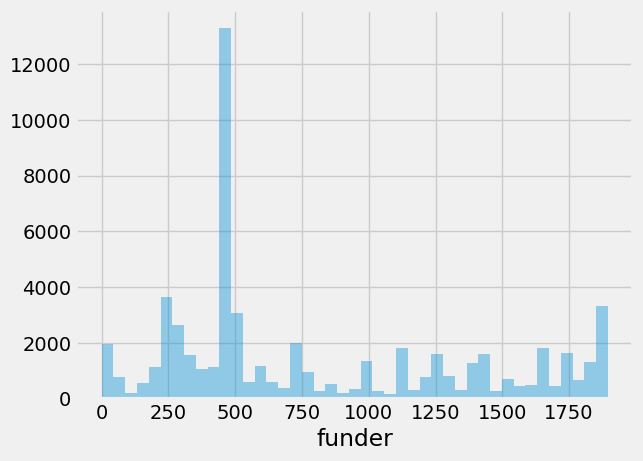

In [ ]:
#Funding Distribution Between Funder and Funds
sns.distplot(train_df["funder"], kde=False)
plt.savefig("Funding Distribution.png")
plt.show()

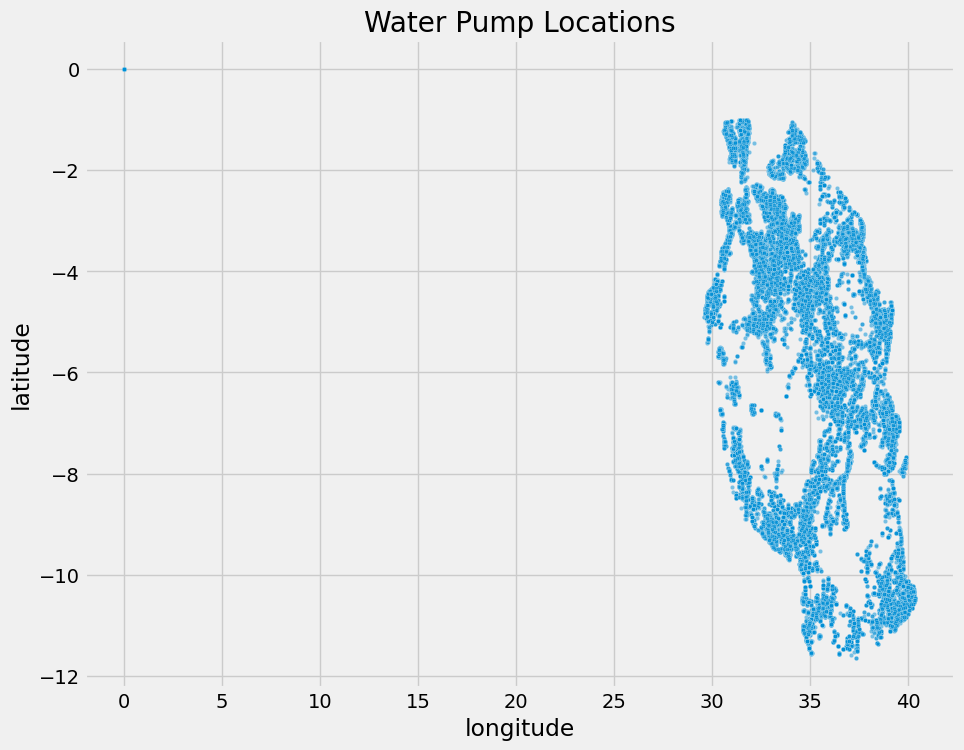

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=train_df, x='longitude', y='latitude', alpha=0.5, s=10)
plt.title('Water Pump Locations')
plt.savefig("Water Pump Locations.png")
plt.show()

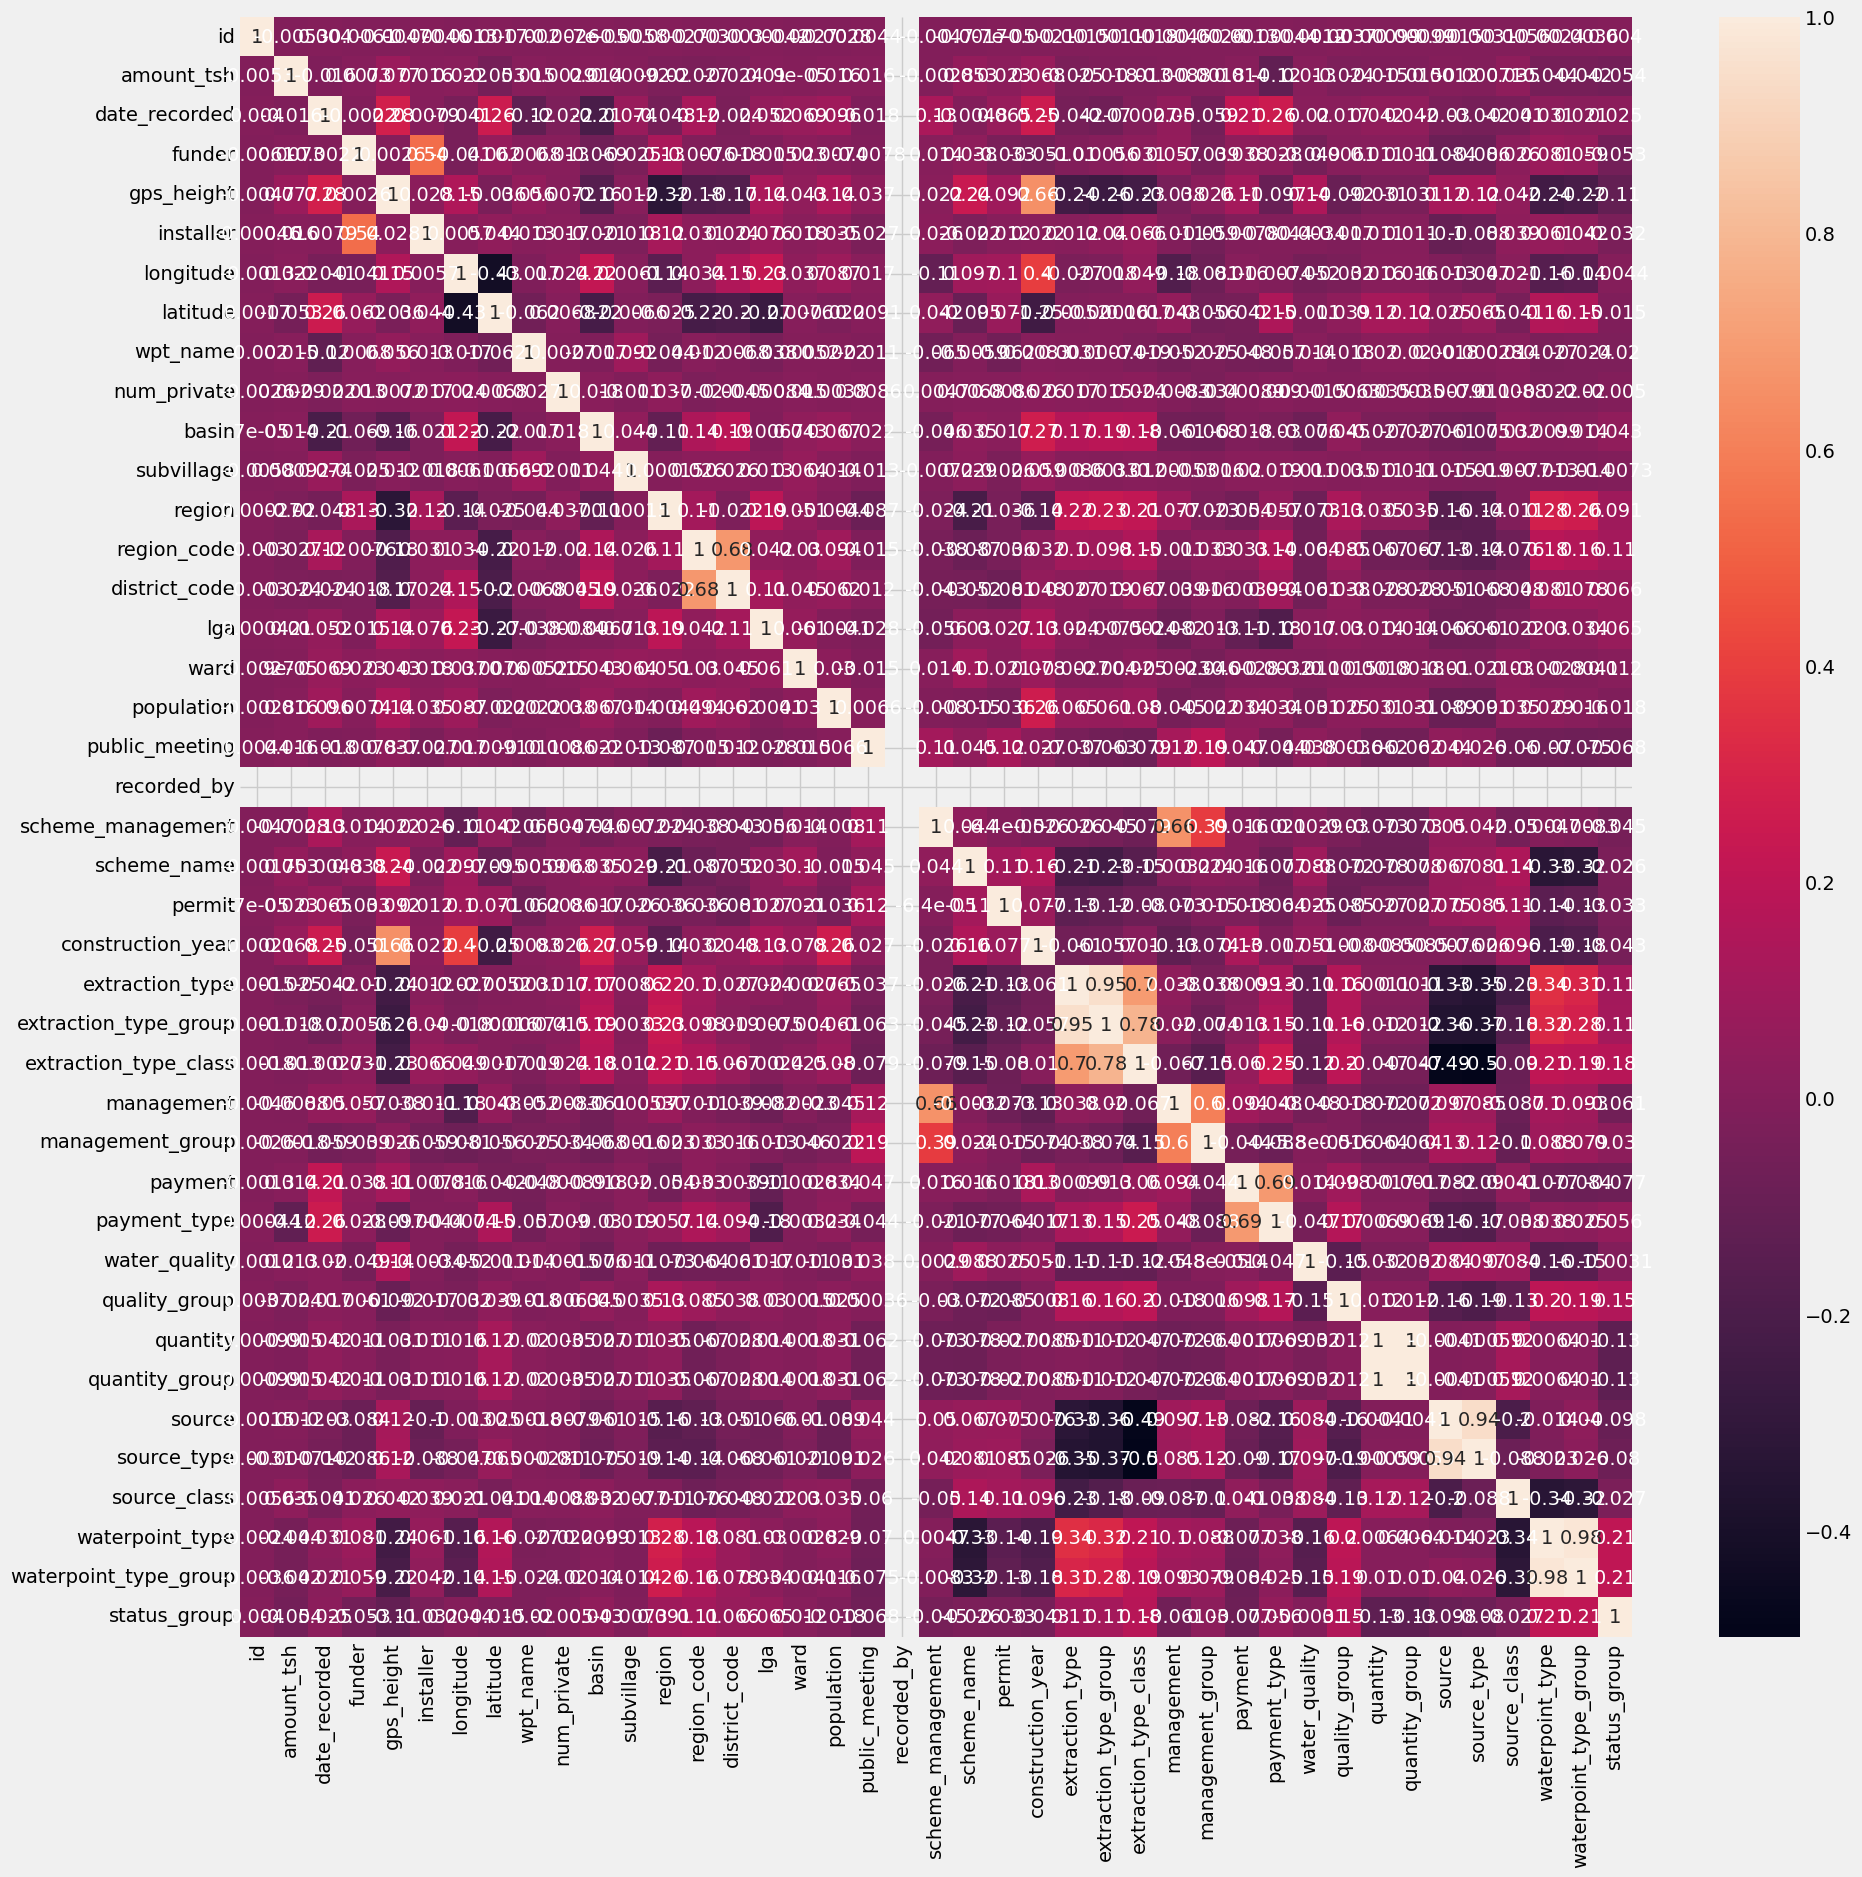

In [ ]:
#Correlation Distribution
corr = train_df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True)
plt.savefig("Correlation Distribution.png")
plt.show()

## Feature Engineering

In [ ]:
def featurize(train_df, test_df, target_col="status_group"):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Drop ID and constant columns
    drop_cols_common = ["id", "recorded_by"]
    train_df = train_df.drop(columns=[c for c in drop_cols_common if c in train_df.columns])
    test_df = test_df.drop(columns=[c for c in drop_cols_common if c in test_df.columns])

    # Drop redundant hierarchical columns
    drop_redundant = [
        "extraction_type", "extraction_type_class",
        "management",
        "payment",
        "water_quality",
        "quantity",
        "source",
        "waterpoint_type"
    ]
    train_df = train_df.drop(columns=[c for c in drop_redundant if c in train_df.columns])
    test_df = test_df.drop(columns=[c for c in drop_redundant if c in test_df.columns])

    # Fix construction_year
    for df in (train_df, test_df):
        if "construction_year" in df.columns:
            df["construction_year"] = df["construction_year"].replace(0, np.nan)

    # Log transform skewed features
    for col in ["population", "amount_tsh"]:
        if col in train_df.columns:
            train_df[col] = np.log1p(train_df[col])
            test_df[col] = np.log1p(test_df[col])

    # Frequency encoding
    high_card_cols = ["funder", "installer", "wpt_name", "subvillage", "ward", "scheme_name"]
    for col in high_card_cols:
        if col in train_df.columns:
            freq = train_df[col].astype(str).value_counts(normalize=True)
            train_df[col] = train_df[col].astype(str).map(freq)
            test_df[col] = test_df[col].astype(str).map(freq).fillna(0)

    # Impute categorical
    cat_cols = [c for c in train_df.select_dtypes(include="object").columns if c != target_col]
    for col in cat_cols:
        imputer = SimpleImputer(strategy="most_frequent")
        train_df[col] = imputer.fit_transform(train_df[[col]]).ravel()
        test_df[col] = imputer.transform(test_df[[col]]).ravel()

    # Label encode categorical
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = test_df[col].map(lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1)

    # Impute numeric
    num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    if target_col in num_cols:
        num_cols.remove(target_col)

    for col in num_cols:
        if train_df[col].isna().any() or test_df[col].isna().any():
            imputer = SimpleImputer(strategy="median")
            train_df[col] = imputer.fit_transform(train_df[[col]]).ravel()
            test_df[col] = imputer.transform(test_df[[col]]).ravel()

    return train_df, test_df

In [ ]:
train_features = pd.read_csv("training_data.csv")
train_labels = pd.read_csv("training_labels.csv")
train_df = pd.merge(train_features, train_labels, on="id")

test_df = pd.read_csv("testing_data.csv")

train_df, test_df = featurize(train_df, test_df)

## Modelling

In [ ]:
lr = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000
    ))
])


gbt = Pipeline([
    ("scaler", RobustScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8
    ))
])

xgb = Pipeline([
    ("scaler", RobustScaler()),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1,
        device="gpu"
    ))
])

lgbm = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=8,
        num_leaves=256,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1,
        device="gpu"
    ))
])

In [ ]:
labels = {"functional": 0, "non functional": 1, "functional needs repair": 2}

train_df["status_group"] = train_df["status_group"].map(lambda x: labels[x])

In [ ]:
X = train_df.drop(columns=["status_group"], axis=1)
y = train_df["status_group"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
models = {
    "Logistic Regression": lr,
    "Gradient Boosting": gbt,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

mlflow.set_experiment("Model Training with Stratified K Fold Cross Validation")
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    with mlflow.start_run(run_name=f"{name}'s Training"):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")

        if y_prob is not None and y_prob.shape[1] > 1:
            roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
        elif y_prob is not None:
            roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            roc_auc = np.nan

        metrics_to_log = {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1)
        }
        if not np.isnan(roc_auc):
            metrics_to_log["roc_auc"] = float(roc_auc)

        for key, value in metrics_to_log.items():
            mlflow.log_metric(key, value, step=0)

        mlflow.log_param("model", name)
        mlflow.sklearn.log_model(model, "model")

        scores = cross_val_score(model, X, y, cv=sk, scoring="f1_macro")
        mlflow.log_metric("cross_val_f1", scores.mean(), step=0)
        mlflow.log_metric("cross_val_std", scores.std(), step=0)

        print(f"{name}'s Metric Statistics:\n")
        for key, value in metrics_to_log.items():
            print(f"{key}: {value}")
        print(f"Cross Validation F1: {scores.mean()}")
        print(f"Cross Validation Std: {scores.std()}\n")

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
        disp.plot()
        plt.savefig(f"{name}_confusion_matrix.png")
        plt.close()

        if y_prob is not None and y_prob.shape[1] > 1:
            fpr = dict()
            tpr = dict()
            for i in range(y_prob.shape[1]):
                fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
                plt.plot(fpr[i], tpr[i], label=f"Class {i}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"{name} ROC Curve")
            plt.legend()
            plt.savefig(f"{name}_roc_curve.png")
            plt.close()

        param_name_map = {
            "Logistic Regression": "model__C",
            "Decision Tree": "model__max_depth",
            "Random Forest": "model__n_estimators",
            "Gradient Boosting": "model__n_estimators",
            "XGBoost": "model__n_estimators",
            "LightGBM": "model__n_estimators"
        }

        param_range_map = {
            "Logistic Regression": [0.01, 0.1, 1, 10],
            "Decision Tree": [3, 5, 10, 20],
            "Random Forest": [100, 200, 300],
            "Gradient Boosting": [100, 200, 300],
            "XGBoost": [100, 200, 300],
            "LightGBM": [100, 200, 300]
        }

        if name in param_name_map:
            param_name = param_name_map[name]
            param_range = param_range_map[name]

            train_scores, valid_scores = validation_curve(
                model, X, y,
                param_name=param_name,
                param_range=param_range,
                cv=sk,
                scoring="f1_macro",
                n_jobs=-1
            )

            train_mean = train_scores.mean(axis=1)
            valid_mean = valid_scores.mean(axis=1)

            plt.figure()
            plt.plot(param_range, train_mean, label="Train")
            plt.plot(param_range, valid_mean, label="Validation")
            plt.xlabel(param_name)
            plt.ylabel("F1 Macro")
            plt.title(f"{name} Validation Curve")
            plt.legend()
            plt.savefig(f"{name}_validation_curve.png")
            plt.close()

            for i, val in enumerate(param_range):
                mlflow.log_metric(f"{param_name}_{val}_train", float(train_mean[i]), step=i+1)
                mlflow.log_metric(f"{param_name}_{val}_valid", float(valid_mean[i]), step=i+1)

2026/03/26 14:37:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 14:37:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#Stacking Ensemble

In [ ]:
stacking = StackingClassifier(
    estimators=[
        ("gbt", gbt),
        ("xgb", xgb),
        ("lgbm", lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False
)

with mlflow.start_run(run_name="Stacking Classifier Training"):
    stacking.fit(X_train, y_train)

    y_pred = stacking.predict(X_test)
    y_prob = stacking.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    if y_prob.shape[1] > 1:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    else:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])

    metrics_to_log = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc)
    }

    for key, value in metrics_to_log.items():
        mlflow.log_metric(key, value)

    mlflow.log_param("model", "StackingClassifier")
    mlflow.sklearn.log_model(stacking, name="model")

    scores = cross_val_score(stacking, X, y, cv=sk, scoring="f1_macro")
    mlflow.log_metric("cross_val_f1", scores.mean())
    mlflow.log_metric("cross_val_std", scores.std())

    print("Stacking Classifier Metrics:\n")
    for key, value in metrics_to_log.items():
        print(f"{key}: {value}")
    print(f"Cross Validation F1: {scores.mean()}")
    print(f"Cross Validation Std: {scores.std()}\n")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot()
    plt.savefig("stacking_confusion_matrix.png")
    plt.close()

    if y_prob.shape[1] > 1:
        for i in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {i}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Stacking ROC Curve")
        plt.legend()
        plt.savefig("stacking_roc_curve.png")
        plt.close()

## Generating the Test Set

In [ ]:
new_test = pd.read_csv("testing_data.csv")
ids = new_test["id"]

In [ ]:
preds = stacking.predict(test_df)

#Retranslate Predictions
num_to_labels = {0: "functional", 1: "non functional", 2: "functional needs repair"}

submission = pd.DataFrame({
    "id": ids,
    "status_group": [num_to_labels[pred] for pred in preds]
})

submission.to_csv("submission.csv", index=False)

In [ ]:
!zip mlflow content/mlruns